## Load data and check for null values

We import the CSV into a DataFrame and check if there are any missing values in each column.

In [2]:
import pandas as pd

df = pd.read_csv("Fuelio_fill_ups.csv")

print(df.shape)
print()
print(df.isnull().sum())
df.head()

(68, 10)

Date                    0
Odometer_km             0
Liters                  0
Full_Tank               0
Cost_EUR                0
Price_Per_Liter_EUR     0
Consumption_l100km      0
Fuel_Type               0
Location               58
Notes                  41
dtype: int64


,Date,Odometer_km,Liters,Full_Tank,Cost_EUR,Price_Per_Liter_EUR,Consumption_l100km,Fuel_Type,Location,Notes
0,2022-11-08,20.0,37.24,Ναι,76.64,2.058,0.000000,Unleaded 98,NaN,NaN
1,2022-11-15,375.0,25.22,Ναι,52.38,2.077,7.104225,Unleaded 98,NaN,NaN
2,2022-11-29,855.0,34.13,Ναι,68.50,2.007,7.110417,Unleaded 95,NaN,NaN
3,2022-12-12,1269.0,31.23,Ναι,54.00,1.729,7.543478,Unleaded 95,NaN,NaN
4,2022-12-21,1734.0,32.70,Ναι,60.00,1.835,7.032258,Unleaded 95,NaN,NaN


## Convert Date column from object to datetime

The `Date` column is loaded as **object** (text). We convert it to **datetime** using `pd.to_datetime()` so we can extract months, years, and calculate time differences later.

In [4]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.dtypes)

Date                   datetime64[ns]
Odometer_km                   float64
Liters                        float64
Full_Tank                      object
Cost_EUR                      float64
Price_Per_Liter_EUR           float64
Consumption_l100km            float64
Fuel_Type                      object
Location                       object
Notes                          object
dtype: object


## Basic statistics

We use `describe()` to get an overview. Note that some stats don't make sense here (e.g. mean date), and we can spot **negative consumption values** which are clearly errors.

In [6]:
df.describe()

,Date,Odometer_km,Liters,Cost_EUR,Price_Per_Liter_EUR,Consumption_l100km
count,68,68.000000,68.000000,68.000000,68.000000,68.000000
mean,2024-04-02 04:35:17.647058944,17247.970588,30.941029,58.912647,1.901956,6.177045
min,2022-11-08 00:00:00,20.000000,10.610000,20.000000,1.729000,-3.824645
25%,2023-06-16 06:00:00,7594.750000,31.655000,57.825000,1.825750,6.633111
50%,2024-04-11 00:00:00,18255.000000,32.765000,61.775000,1.889000,7.035652
75%,2024-11-16 06:00:00,25281.500000,33.935000,65.105000,1.977500,7.295173
max,2025-09-21 00:00:00,33190.000000,37.240000,76.640000,2.089000,11.973684
std,NaN,9973.633681,5.893988,12.117876,0.101111,2.818966


## Find invalid consumption entries

Let's find which records have **negative or zero** consumption — these are data errors from the Fuelio app (likely caused by missed fill-ups).

In [8]:
# Find entries with negative or zero consumption
df[df['Consumption_l100km'] <= 0]

,Date,Odometer_km,Liters,Full_Tank,Cost_EUR,Price_Per_Liter_EUR,Consumption_l100km,Fuel_Type,Location,Notes
0,2022-11-08,20.0,37.24,Ναι,76.64,2.058,0.000000,Unleaded 98,NaN,NaN
18,2023-09-15,10840.0,34.29,Ναι,68.51,1.998,0.000000,Unleaded 95,NaN,NaN
19,2023-09-26,11257.0,31.75,Ναι,66.01,2.079,0.000000,Unleaded 98,NaN,NaN
34,2024-04-17,18491.0,32.24,Ναι,64.00,1.985,0.000000,Unleaded 95,Nea Erithrea - Shell,before 63 | cosmote 707966866 | Car: 6.2
35,2024-04-26,18974.0,33.70,Ναι,68.01,2.018,0.000000,Unleaded 95,Nea Erithrea - Shell,577891800 cosmote code | 42km left | 6.1l/100
56,2025-02-13,27715.0,32.18,Όχι,59.87,1.865,0.000000,Unleaded 98,Shell - Nea Erithrea,459609509 cosmote | 6.7/100 | 63km left |
63,2025-09-01,31782.0,33.16,Ναι,58.00,1.749,-0.420000,Unleaded 95,NaN,NaN
66,2025-09-15,32852.0,22.93,Ναι,40.00,1.745,-3.824645,Unleaded 95,NaN,NaN


## Create a cleaned consumption column

Instead of deleting the bad rows entirely (we still need their cost/liters data), we create a new column `Consumption_clean` that keeps only positive values and sets the rest to NaN.

In [10]:
df['Consumption_clean'] = df['Consumption_l100km'].where(df['Consumption_l100km'] > 0)

print(f"Valid entries: {df['Consumption_clean'].notna().sum()}")
print(f"Mean consumption: {df['Consumption_clean'].mean():.2f} l/100km")

Valid entries: 60
Mean consumption: 7.07 l/100km


## Q1: How does fuel price change over time?

Using matplotlib, we plot the price per liter over time. Each dot is one fill-up. The first argument in `plt.plot()` is the x-axis (Date), so whenever we want to show something **over time**, the date goes first.

- `marker='o'` draws circles at each data point (could also be `'x'`)
- `tight_layout()` adjusts spacing so nothing gets cut off

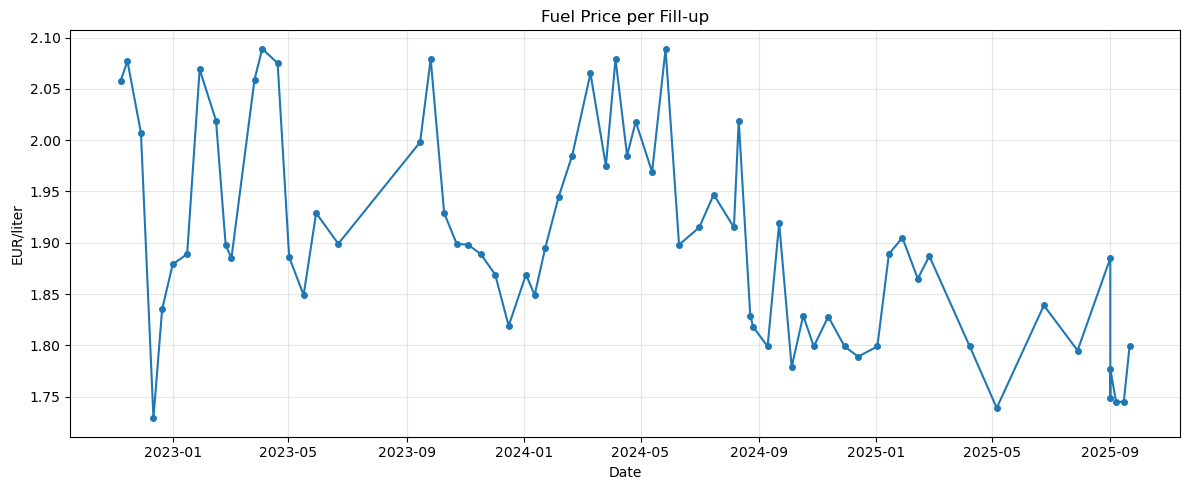

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Price_Per_Liter_EUR'], marker='o', markersize=4)
plt.title('Fuel Price per Fill-up')
plt.xlabel('Date')
plt.ylabel('EUR/liter')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q2: Price per liter by fuel type

The zigzag pattern above is because we alternate between Unleaded 95 and 98. Here we split them using a **for loop** + **boolean mask**.

For each unique fuel type, `mask` stores a True/False series. Then `df.loc[mask, column]` selects only the rows where mask is True — this is how `.loc` works: `df.loc[rows, columns]`.

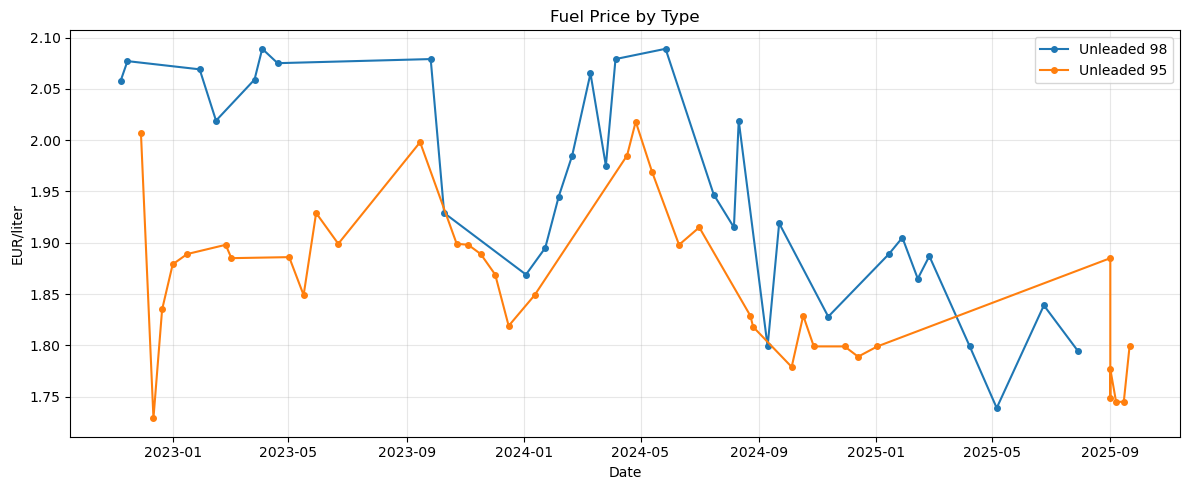

In [14]:
plt.figure(figsize=(12, 5))

for fuel_type in df['Fuel_Type'].unique():
    mask = df['Fuel_Type'] == fuel_type
    plt.plot(df.loc[mask, 'Date'], 
             df.loc[mask, 'Price_Per_Liter_EUR'], 
             marker='o', markersize=4, label=fuel_type)

plt.title('Fuel Price by Type')
plt.xlabel('Date')
plt.ylabel('EUR/liter')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q3: Consumption over time by fuel type

Same approach as above, but plotting the cleaned consumption column instead of price.

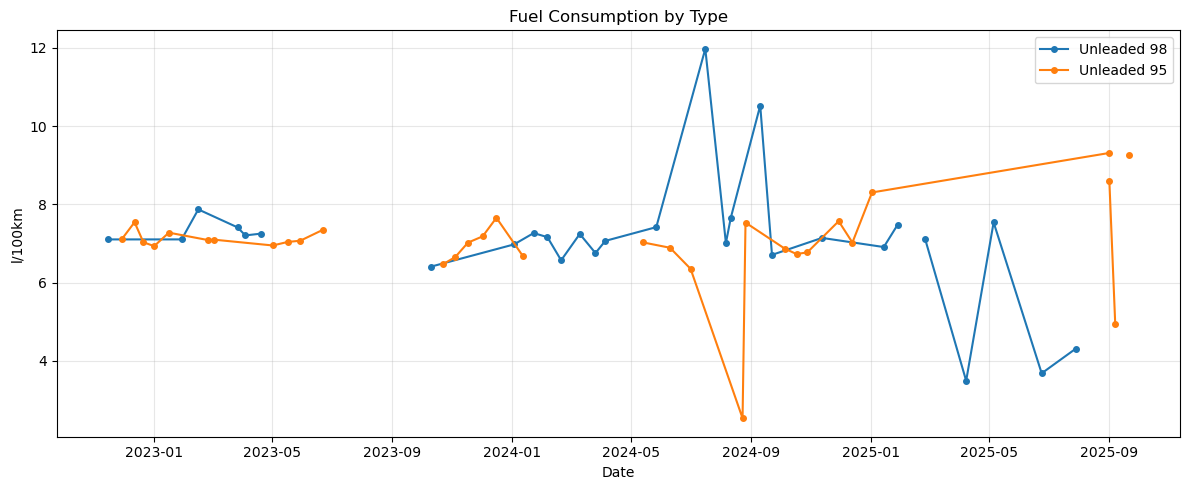

In [16]:
plt.figure(figsize=(12, 5))

for fuel_type in df['Fuel_Type'].unique():
    mask = df['Fuel_Type'] == fuel_type
    plt.plot(df.loc[mask, 'Date'], 
             df.loc[mask, 'Consumption_clean'], 
             marker='o', markersize=4, label=fuel_type)

plt.title('Fuel Consumption by Type')
plt.xlabel('Date')
plt.ylabel('l/100km')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q4: Which fuel type has lower consumption? (Box Plot)

We first clean the data by keeping only rows with valid consumption using `notna()` and `copy()`. Then we use seaborn's **boxplot** to compare the two fuel types.

**Result:** There is virtually no difference in consumption between Unleaded 95 and 98.

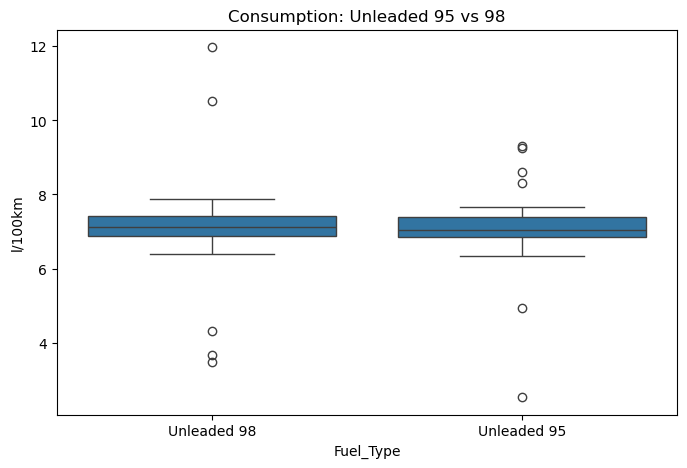

In [18]:
import seaborn as sns

# Keep only entries with valid consumption
df_clean = df[df['Consumption_clean'].notna()].copy()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Fuel_Type', y='Consumption_clean')
plt.title('Consumption: Unleaded 95 vs 98')
plt.ylabel('l/100km')
plt.show()

## Q5: How much more expensive is Unleaded 98?

Using `groupby()` + `mean()` we compare the average price and consumption for each fuel type.

**Finding:** Unleaded 98 costs ~0.10 EUR/liter more on average, with **no improvement** in consumption. That's about 3.30 EUR wasted per fill-up.

In [20]:
print(df_clean.groupby('Fuel_Type')['Price_Per_Liter_EUR'].mean())
print()
print(df_clean.groupby('Fuel_Type')['Consumption_clean'].mean())

Fuel_Type
Unleaded 95    1.854281
Unleaded 98    1.946393
Name: Price_Per_Liter_EUR, dtype: float64

Fuel_Type
Unleaded 95    7.059259
Unleaded 98    7.085266
Name: Consumption_clean, dtype: float64


## Q6: How many km between fill-ups?

We use `.diff()` to calculate the difference in odometer readings between consecutive fill-ups. Since the data is sorted chronologically, this gives us the distance driven between each fill-up.

In [22]:
# Calculate km difference between consecutive fill-ups
df['Km_Between'] = df['Odometer_km'].diff()

print(df['Km_Between'].describe())

count      67.000000
mean      495.074627
std       347.326905
min       146.000000
25%       428.000000
50%       465.000000
75%       490.500000
max      3135.000000
Name: Km_Between, dtype: float64


### Investigating the 3135 km outlier

The max of 3135 km seems too high — likely a period where several fill-ups were not recorded.

In [24]:
# Which fill-up had the 3135 km gap?
df[df['Km_Between'] == df['Km_Between'].max()][['Date', 'Odometer_km', 'Km_Between', 'Notes']]

,Date,Odometer_km,Km_Between,Notes
18,2023-09-15,10840.0,3135.0,NaN


## Q7: Distribution of km between fill-ups (Histogram)

A histogram splits values into bins and counts how many fall in each. Most fill-ups happen every **350-550 km**, which makes sense for a 35L tank at ~7 l/100km.

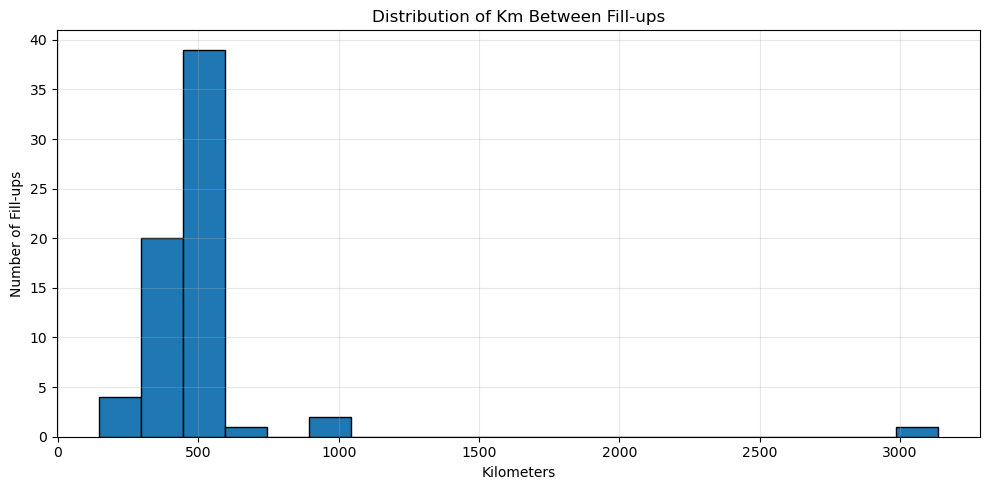

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(df['Km_Between'].dropna(), bins=20, edgecolor='black')
plt.title('Distribution of Km Between Fill-ups')
plt.xlabel('Kilometers')
plt.ylabel('Number of Fill-ups')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Q8: Monthly fuel cost

`.dt.to_period('M')` converts a date to a month period (e.g. 2024-03). Then we `groupby` that period and `sum()` the cost.

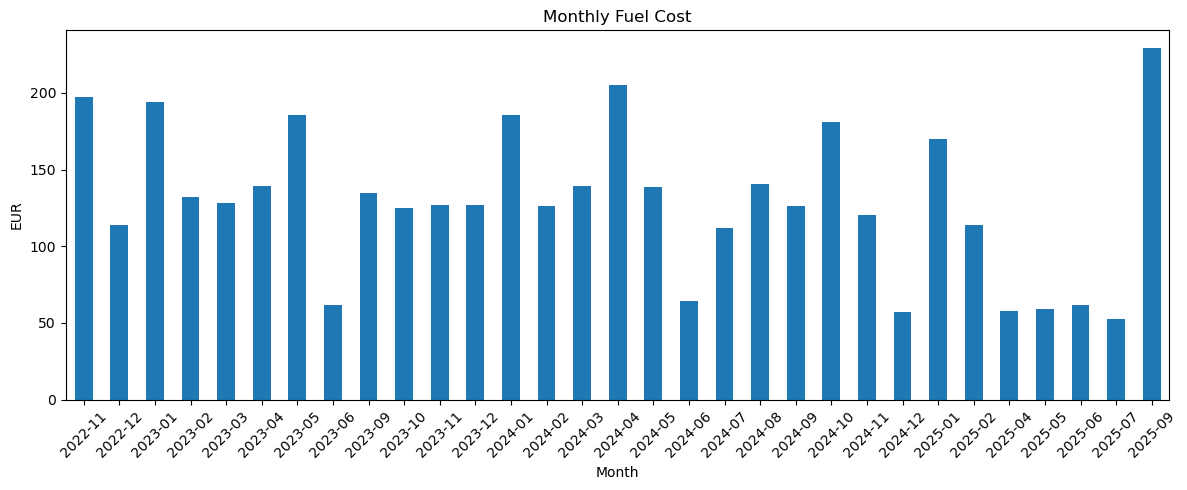

Average monthly cost: 129.23 EUR


In [28]:
# Extract month/year from date
df['Month'] = df['Date'].dt.to_period('M')

# Sum cost per month
monthly_cost = df.groupby('Month')['Cost_EUR'].sum()

plt.figure(figsize=(12, 5))
monthly_cost.plot(kind='bar')
plt.title('Monthly Fuel Cost')
plt.xlabel('Month')
plt.ylabel('EUR')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Average monthly cost: {monthly_cost.mean():.2f} EUR")

## Q9: Does consumption change by season?

We create a custom function `get_season()` and apply it to each row using `.apply()`. This maps each month number to a season name.

**Finding:** Summer has *lower* consumption due to highway driving (cruise control, steady speed), which outweighs the A/C effect. City stop-and-go driving in other seasons burns more fuel.

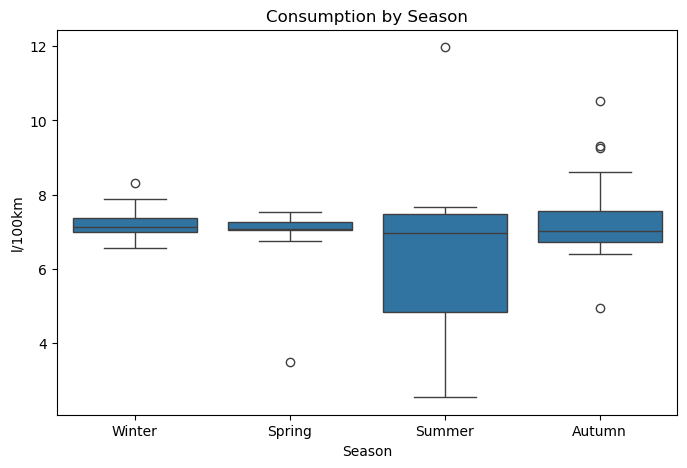

In [30]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Date'].dt.month.apply(get_season)

plt.figure(figsize=(8, 5))
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
sns.boxplot(data=df, x='Season', y='Consumption_clean', order=season_order)
plt.title('Consumption by Season')
plt.ylabel('l/100km')
plt.show()

## Q10: Cumulative fuel cost over time

`.cumsum()` calculates a running total — each row shows total spent **up to that point**. If the slope changes somewhere, it means spending sped up or slowed down during that period.

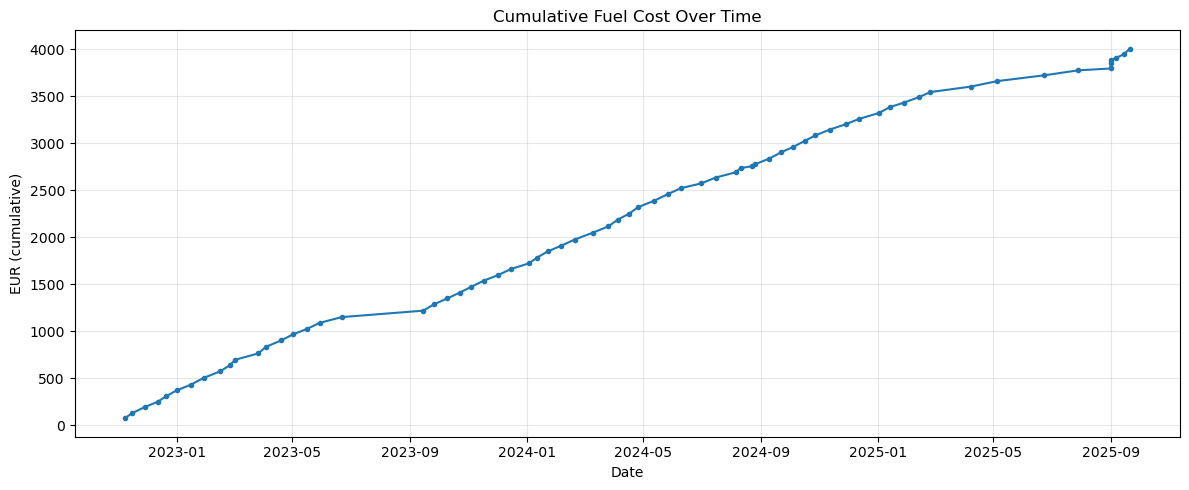

Total spent: 4006.06 EUR


In [32]:
df['Total_Cost'] = df['Cost_EUR'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Total_Cost'], marker='o', markersize=3)
plt.title('Cumulative Fuel Cost Over Time')
plt.xlabel('Date')
plt.ylabel('EUR (cumulative)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total spent: {df['Total_Cost'].iloc[-1]:.2f} EUR")

## Q11: How often do I fill up? (Days between fill-ups)

`.diff()` on a datetime column gives a timedelta, and `.dt.days` extracts just the number of days.

**Result:** Median is ~14 days, so roughly every 2 weeks.

In [34]:
df['Days_Between'] = df['Date'].diff().dt.days

print(df['Days_Between'].describe())

count    67.000000
mean     15.641791
std      11.931244
min       0.000000
25%      11.000000
50%      14.000000
75%      16.000000
max      85.000000
Name: Days_Between, dtype: float64
